# Daily forecast of financial time series group questions

## Forecast

In [ ]:
import matplotlib.pylab as plt
from get_market_pulse_25q3_questions import get_market_pulse_25q3_questions
from get_underlying_urls import get_underlying_urls
from urls_to_ticker import urls_to_ticker
from pprint import pprint
from get_data_for import get_data_for
from get_forward_period_start_and_end_date import get_forward_period_start_and_end_date
from get_observable import get_observable
from get_period_type import get_period_type
import pandas as pd
from forecast_high_on_any_day_in_forward_period import forecast_high_on_any_day_in_forward_period
from forecast_close_on_last_day_of_period import forecast_close_on_last_day_of_period
from forecast_stock_price_return_spread import forecast_stock_price_return_spread
from forecast_futures_total_price_return_spread import forecast_futures_total_price_return_spread
from forecast_quarter_diluted_eps_on_next_filing_date import forecast_quarter_diluted_eps_on_next_filing_date
from metaculus_generate_continuous_cdf import metaculus_generate_continuous_cdf
from standardize_cdf import standardize_cdf
from post_group_forecast import post_group_forecast
from forecast_general_binary import forecast_general_binary
from ensure_min_increase import ensure_min_increase
import os

pd.set_option('display.max_colwidth', 1000)

In [2]:
# Get open questions
ifps = get_market_pulse_25q3_questions()

200


In [3]:
results = get_underlying_urls(ifps)
results = {int(key): value for key, value in results.items()}
group_id_to_data = {int(x): results[x] for x in results}

# Acquire question data
sources = []
for key, (title, urls) in results.items():
    sources.extend(urls_to_ticker(urls))

sources = list(sorted(set(sources)))
history = {(x,y,z): get_data_for(x,y,z) for x,y,z in sources}

START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.3263715386390686

```python
[
    "https://en.wikipedia.org/wiki/S%26P_500",
    "https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices",
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S%26P_500_component_stocks",
    "https://en.wikipedia.org/wiki/Ares_Management",
    "https://en.wikipedia.org/wiki/MicroStrategy",
    "https://en.wikipedia.org/wiki/The_Trade_Desk",
    "https://en.wikipedia.org/wiki/Robinhood_Markets",
    "https://en.wikipedia.org/wiki/Datadog",
    "https://www.spglobal.com/"
]
```
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistral-small3.2:24b-instruct-2506-q4_K_M minutes 0.02989796797434489

```python
["https://en.wikipedia.org/wiki/VIX", "https://www.tradingview.com/symbols/CBOE-VIX/", "https://www.cboe.com/tradable_products/vix/vix_historical_data/"]
```
START model mistral-small3.2:24b-instruct-2506-q4_K_M
model mistr

/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  

In [4]:
for i, ifp in enumerate(ifps):
    # Organize data
    ifp['sources'] = urls_to_ticker(results[ifp['group']['id']][1])

DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices
DK https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S%26P_500_component_stocks
DK https://en.wikipedia.org/wiki/Ares_Management
DK https://en.wikipedia.org/wiki/MicroStrategy
DK https://en.wikipedia.org/wiki/The_Trade_Desk
DK https://en.wikipedia.org/wiki/Robinhood_Markets
DK https://en.wikipedia.org/wiki/Datadog
DK https://www.spglobal.com/
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_Indices
DK https://en.wikipedia.org/wiki/List_of_S%26P_500_companies#S%26P_500_component_stocks
DK https://en.wikipedia.org/wiki/Ares_Management
DK https://en.wikipedia.org/wiki/MicroStrategy
DK https://en.wikipedia.org/wiki/The_Trade_Desk
DK https://en.wikipedia.org/wiki/Robinhood_Markets
DK https://en.wikipedia.org/wiki/Datadog
DK https://www.spglobal.com/
DK https://en.wikipedia.org/wiki/S%26P_500
DK https://en.wikipedia.org/wiki/S%26P_Dow_Jones_In

In [5]:
for i, ifp in enumerate(ifps):
    ifp['data'] = {x: history[x] for x in ifp['sources']}

In [6]:
for i, ifp in enumerate(ifps):
    if 'following companies' in ifp['title']:
        company = ifp['title'].split('(')[1].split(')')[0]
        ifp['sources'] = [(x,y,z) for x,y,z in ifp['sources'] if y == company]
        ifp['data'] = {(x,y,z):w for (x,y,z),w in ifp['data'].items() if y == company}

In [7]:
ifp['sources']

[('macrotrends', 'AMZN', 'revenue')]

In [ ]:
for i, ifp in enumerate(ifps):
    # Get forward period start and end date
    if 'period' not in ifp or not ifp['period']:
        ifp['period'] = get_forward_period_start_and_end_date(ifp)

In [9]:
for i, ifp in enumerate(ifps):
    # Parse observable of data
    if 'observable' not in ifp:
        ifp['observable'] = get_observable(ifp)

In [10]:
for i, ifp in enumerate(ifps):
    if 'period_type' not in ifp:
        ifp['period_type'] = get_period_type(ifp)

In [ ]:
for i, ifp in enumerate(ifps):
    fn = f'glimt/forecast/{ifp["id"]}.json'
    if os.path.exists(fn):
          continue
    # Generate forecast for each question
    print(f"[{i}] {ifp['id']} {ifp['title']}")
    ifp['forecast'] = """Statistical analysis."""
    ifp['question_type'] = 'numeric'
    ### High on any day in forward biweekly period from today
    (observable, period_type) = (ifp['observable'], ifp['period_type'])
    if observable == 'High' and period_type == 'any day in biweekly period':
        print("******forecast_high_on_any_day_in_forward_period")
        rng, prediction = forecast_high_on_any_day_in_forward_period(ifp)
    ### Close on last day of biweekly period
    elif observable == 'Close' and period_type == 'last day of biweekly period':
        print("******forecast_close_on_last_day_of_period")
        rng, prediction = forecast_close_on_last_day_of_period(ifp)
    ### period stock price return on last vs first day of biweekly period
    elif (observable, period_type) == ('stock price Close return', 'return on last vs first day of biweekly period'):
        print("*** forecast_stock_price_return_spread")
        rng, prediction = forecast_stock_price_return_spread(ifp)
    ### period futures total price return on last vs first day of biweekly period
    elif (observable, period_type) == ('futures total price Close return', 'return on last vs first day of biweekly period'):
        print("*******forecast_futures_total_price_return_spread")
        rng, prediction = forecast_futures_total_price_return_spread(ifp)
    ### quarter diluted eps on next SEC filing date	
    elif (observable, period_type) == ('quarter diluted eps', 'next SEC filing date'):
        print("********forecast_quarter_diluted_eps_on_next_filing_date")
        rng, prediction = forecast_quarter_diluted_eps_on_next_filing_date(ifp)
    ### quarter total revenue on next SEC filing date	
    elif (observable, period_type)  == ('quarter total revenue', 'next SEC filing date'):
        print("*********forecast_quarter_diluted_eps_on_next_filing_date")
        rng, prediction = forecast_quarter_diluted_eps_on_next_filing_date(ifp)
    elif ifp['title'].startswith('Will '):
        print("BINARY")
        forecast_general_binary(ifp)
        continue
    else:
        raise Exception(f"Unhandled question [{ifp['id']}] {ifp['title']} {observable} {period_type}")
    ifp['prediction'] = prediction

In [31]:
import os, requests, json
from load_secrets import load_secrets
load_secrets()

METACULUS_TOKEN = os.getenv('METACULUS_TOKEN')
AUTH_HEADERS = {"headers": {"Authorization": f"Token {METACULUS_TOKEN}"}}
API_BASE_URL = "https://www.metaculus.com/api"

def create_forecast_payload(
    forecast: float | dict[str, float] | list[float],
    question_type: str,
) -> dict:
    """
    Accepts a forecast and generates the api payload in the correct format.

    If the question is binary, forecast must be a float.
    If the question is multiple choice, forecast must be a dictionary that
      maps question.options labels to floats.
    If the question is numeric, forecast must be a dictionary that maps
      quartiles or percentiles to datetimes, or a 201 value cdf.
    """
    if question_type == "binary":
        return {
            "probability_yes": forecast,
            "probability_yes_per_category": None,
            "continuous_cdf": None,
        }
    if question_type == "multiple_choice":
        return {
            "probability_yes": None,
            "probability_yes_per_category": forecast,
            "continuous_cdf": None,
        }
    # numeric or date
    return {
        "probability_yes": None,
        "probability_yes_per_category": None,
        "continuous_cdf": forecast,
    }

def post_question_prediction(question_id: int, forecast_payload: dict) -> None:
    """
    Post a forecast on a question.
    """
    url = f"{API_BASE_URL}/questions/forecast/"
    response = requests.post(
        url,
        json=[
            {
                "question": question_id,
                **forecast_payload,
            },
        ],
        **AUTH_HEADERS,  # type: ignore
    )
    print(f"Prediction Post status code: {response.status_code}")
    if not response.ok:
        raise RuntimeError(response.text)


def post_question_comment(post_id: int, comment_text: str) -> None:
    """
    Post a comment on the question page as the bot user.
    """
    response = requests.post(
        f"{API_BASE_URL}/comments/create/",
        json= {
            "text": comment_text,
            "parent": None,
            "included_forecast": True,
            "is_private": True,
            "on_post": post_id,
        },
        **AUTH_HEADERS,  # type: ignore
    )
    if not response.ok:
        raise RuntimeError(response.text)

def post_group_forecast(row):
    question_id = int(row.id_of_question)
    post_id = int(row.id_of_post)
    question_type = row.question_type
    forecast = row.prediction
    comment = row.forecast
    forecast_payload = create_forecast_payload(forecast, question_type)
    post_question_prediction(question_id, forecast_payload)
    post_question_comment(post_id, comment)
    print("Posted forecast for", question_id)
    dfn = f'glimt/forecast'
    dfn = f'glimt/forecast'
    os.makedirs(dfn, exist_ok=True)
    fn = f"{dfn}/{question_id}.json"
    result = (forecast, comment, '', '')
    with open(fn, 'w') as f:
        json.dump(result, f)




In [33]:
from smooth_percentiles import smooth_percentiles

for i, ifp in enumerate(ifps):   
    try:
        if type(ifp['prediction']) == float:
            ifp['question_type'] = 'binary'
    except:
        print('missing', ifp['id'])
    # Submit the question
    row = pd.Series()
    row['id_of_question'] = ifp['id']
    row['id_of_post'] = ifp['post_id']
    row['question_type'] = ifp['question_type']
    row['forecast'] = ifp['forecast']
    if ifp['question_type'] == 'numeric':
        p1 = ifp['prediction']
        p1[0] = ifp['scaling']['range_min']
        p1[-1] = ifp['scaling']['range_max']
        p1 = ensure_min_increase(p1)
        p2 = dict(zip(rng,p1))
        p4 = metaculus_generate_continuous_cdf(p2, ifp)
        p5 = standardize_cdf(p4, ifp['scaling'])
        row['prediction'] = p5
        ifp['cdf'] = p5
    elif ifp['question_type'] == 'binary':
        continue # already posted
    else:
        raise Exception(ifp['question_type'])

    post_group_forecast(row)

Prediction Post status code: 201
Posted forecast for 38212
Prediction Post status code: 201
Posted forecast for 38213
Prediction Post status code: 201
Posted forecast for 38207
Prediction Post status code: 201
Posted forecast for 38208
Prediction Post status code: 201
Posted forecast for 38209
Prediction Post status code: 201
Posted forecast for 38211
Prediction Post status code: 201
Posted forecast for 38210
Prediction Post status code: 201
Posted forecast for 38214
Prediction Post status code: 201
Posted forecast for 38165
Prediction Post status code: 201
Posted forecast for 38166
Prediction Post status code: 201
Posted forecast for 38267
Prediction Post status code: 201
Posted forecast for 38169
Prediction Post status code: 201
Posted forecast for 38170
Prediction Post status code: 201
Posted forecast for 38266


## Crowd alignment

In [45]:
import numpy as np

def normalized_cdf_distance(cdf1, cdf2):
    """
    Computes a normalized distance metric between two CDFs defined as 
    201-element arrays on percentiles from 0% to 100%.

    The distance is normalized so that distance=0 indicates identical CDFs,
    and distance=1 indicates maximally different CDFs.

    Parameters:
    cdf1, cdf2 : np.ndarray
        Arrays of length 201 representing cumulative probabilities at percentiles 0, 0.5, ..., 100.

    Returns:
    float
        Normalized distance metric between 0 and 1.
    """
    cdf1 = np.asarray(cdf1)
    cdf2 = np.asarray(cdf2)
    
    # Absolute differences at each percentile
    abs_diff = np.abs(cdf1 - cdf2)
    
    # Since grid is uniform from 0% to 100% with 201 points, spacing is 0.005 = 0.5%
    grid_spacing = 0.005
    
    # Area (sum) between the two CDF curves - approximate integral
    area_diff = np.sum(abs_diff) * grid_spacing
    
    # Maximum possible area_diff is 1 (e.g., cdf1=0 everywhere, cdf2=1 everywhere)
    normalized_distance = area_diff / 1.0
    
    return normalized_distance


In [60]:
import numpy as np
import pandas as pd
rows = []
for ifp in ifps:
    forecast = [ifp['prediction'], 1-ifp['prediction']] if ifp['type'] == 'binary' else ifp['cdf']
    crowd = ifp['aggregations']['recency_weighted']['latest']['forecast_values']
    distance = None
    if ifp['type'] == 'binary':
        distance = abs(forecast[0]-crowd[0])
    else:
        distance = normalized_cdf_distance(forecast, crowd)
    rows.append((ifp['id'], ifp['title'], distance))
df = pd.DataFrame(rows, columns = ('id', 'title', 'distance')).sort_values(by='distance')

In [61]:
df

,id,title,distance
10,38214,What will be the ending value of the UST 10Y Yield for the following biweekly periods? (Aug 4 - Aug 15),0.030788
13,38267,What will the first reported earnings per share after June 2025 be for the following companies? (AMZN),0.035917
3,38212,"What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (Aug 4 - Aug 15)",0.036531
4,38213,What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Aug 4 - Aug 15),0.052402
8,38211,How much will Nasdaq-100 Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15),0.076689
11,38165,What will the first reported earnings per share after June 2025 be for the following companies? (AAPL),0.098036
9,38210,How much will Gold Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15),0.098271
6,38208,How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15),0.107880
5,38207,How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Aug 4 - Aug 15),0.126678
1,37915,Will the following companies be added to the S&P 500 before October 2025? (HOOD),0.140000


<Axes: >

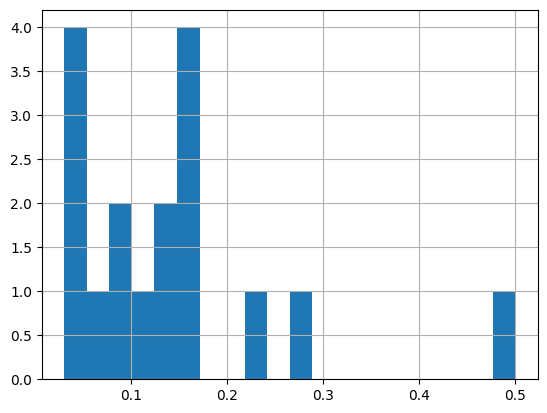

In [65]:
df.distance.hist(bins=20)